In [6]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0


In [11]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


In [12]:
model = models.Sequential()

# Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


C:\Users\abdul\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [14]:
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.9609 - loss: 0.1279 - val_accuracy: 0.9857 - val_loss: 0.0399
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9870 - loss: 0.0424 - val_accuracy: 0.9900 - val_loss: 0.0297
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9909 - loss: 0.0288 - val_accuracy: 0.9888 - val_loss: 0.0358
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9917 - val_loss: 0.0252
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9953 - loss: 0.0144 - val_accuracy: 0.9920 - val_loss: 0.0268


In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9920 - loss: 0.0268
Test Accuracy: 0.9919999837875366


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


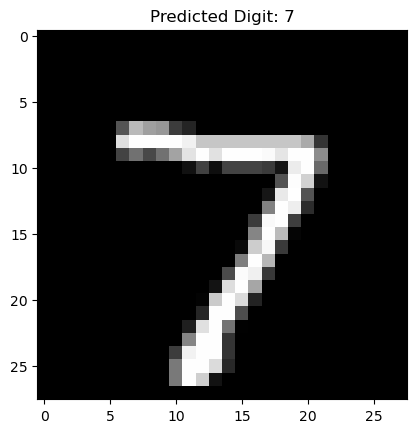

In [16]:
prediction = model.predict(x_test)

plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted Digit: " + str(np.argmax(prediction[0])))
plt.show()
